In [ ]:
# COMPLETE TRADITIONAL CAD PIPELINE - Challenge 1
# Digital Image → Lesion Detection → Feature Extraction → Feature Selection → Classifier → Diagnosis

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# Import Libraries

import os
import cv2
import numpy as np
import pandas as pd
from glob import glob
from tqdm import tqdm
from skimage.color import rgb2gray
from skimage.feature import local_binary_pattern
from skimage import morphology, measure
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pickle

# Paths

DATASET_DIR = "/content/drive/MyDrive/MIC_UdG/CAD_Lab/Challenge_1/Train_Validation"
MODEL_DIR   = "/content/drive/MyDrive/MIC_UdG/CAD_Lab/Challenge_1/Models"
RESULTS_DIR = "/content/drive/MyDrive/MIC_UdG/CAD_Lab/Challenge_1/Results"
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

MODEL_PATH  = os.path.join(MODEL_DIR, "trained_ensemble_complete.pkl")
OUTPUT_CSV  = os.path.join(RESULTS_DIR, "predictions.csv")


# Digital Image + Lesion Detection

def read_and_segment(path, target_size=(256,256)):
    img = cv2.imread(path)
    if img is None:
        raise ValueError(f"Cannot read {path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, target_size)

    # HSV thresholding to detect lesion area
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
    h, s, v = cv2.split(hsv)
    _, mask = cv2.threshold(s, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Morphological cleanup
    mask = morphology.remove_small_objects(mask.astype(bool), 150)
    mask = morphology.remove_small_holes(mask, 150)
    mask = mask.astype(np.uint8) * 255

    # Keep largest region
    labels = measure.label(mask)
    if labels.max() > 0:
        largest = 1 + np.argmax(np.bincount(labels.flat)[1:])
        mask = (labels == largest).astype(np.uint8) * 255

    segmented = cv2.bitwise_and(img, img, mask=mask)
    return segmented

# Feature Extraction

def color_histogram_features(img, bins=(32,32,32), space='rgb'):
    if space.lower() == 'hsv':
        img = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
    chans = cv2.split(img)
    feats = []
    for i, ch in enumerate(chans):
        hist = cv2.calcHist([ch], [0], None, [bins[i]], [0,256]).flatten()
        hist /= (hist.sum() + 1e-9)
        feats.extend(hist.tolist())
    return np.array(feats, dtype=np.float32)

def color_moments(img):
    chans = cv2.split(img.astype(np.float32))
    feats = []
    for ch in chans:
        mean, std = ch.mean(), ch.std()
        skew = ((ch - mean)**3).mean() / (std**3 + 1e-9)
        feats.extend([mean, std, skew])
    return np.array(feats, dtype=np.float32)

def lbp_histogram(img_gray, P=8, R=7, n_bins=59):
    lbp = local_binary_pattern(img_gray, P, R, method="uniform")
    hist, _ = np.histogram(lbp.ravel(), bins=np.arange(0, n_bins+1), range=(0, n_bins))
    hist = hist.astype("float32")
    hist /= (hist.sum() + 1e-9)
    return hist

def extract_features(path, target_size=(256,256)):
    img = read_and_segment(path, target_size)
    rgb_hist = color_histogram_features(img, (32,32,32), 'rgb')
    hsv_hist = color_histogram_features(img, (16,16,16), 'hsv')
    gray = (rgb2gray(img) * 255).astype(np.uint8)
    lbp_hist = lbp_histogram(gray)
    moments = color_moments(img)
    return np.concatenate([rgb_hist, hsv_hist, lbp_hist, moments])

# Build Dataset (Features + Labels)

def build_dataset(dataset_dir):
    features, labels = [], []
    exts = ("*.jpg","*.jpeg","*.png","*.JPG","*.JPEG","*.PNG")
    imgs = []
    for ext in exts:
        imgs.extend(glob(os.path.join(dataset_dir, "**", ext), recursive=True))
    if not imgs:
        raise ValueError(f"No images found in {dataset_dir}")

    print(f" Found {len(imgs)} images")
    for p in tqdm(imgs, desc="Extracting features"):
        try:
            feat = extract_features(p)
            label = 0 if "nevus" in p.lower() else 1
            features.append(feat)
            labels.append(label)
        except Exception as e:
            print(p, e)
    return np.vstack(features), np.array(labels, dtype=int)

print("Loading dataset...")
X, y = build_dataset(DATASET_DIR)
print("Feature matrix shape:", X.shape)

# Feature Scaling + Selection

scaler = StandardScaler()
X_s = scaler.fit_transform(X)

selector = SelectKBest(score_func=f_classif, k=200)
X_sel = selector.fit_transform(X_s, y)
print(f"Selected top {X_sel.shape[1]} features out of {X_s.shape[1]}")

# Classification

X_train, X_val, y_train, y_val = train_test_split(X_sel, y, test_size=0.2, stratify=y, random_state=42)

knn = KNeighborsClassifier(n_neighbors=5)
svm = SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=42)
rf  = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
mlp = MLPClassifier(hidden_layer_sizes=(256,128), max_iter=300, random_state=42)

print("\n Training models...")
for m in [knn, svm, rf, mlp]:
    m.fit(X_train, y_train)

ensemble = VotingClassifier(estimators=[('knn', knn), ('svm', svm), ('rf', rf), ('mlp', mlp)], voting='hard')
ensemble.fit(X_train, y_train)

models = {'KNN': knn, 'SVM': svm, 'RF': rf, 'MLP': mlp, 'Ensemble': ensemble}

# Diagnosis / Evaluation

print("\n Validation Results:")
for name, m in models.items():
    preds = m.predict(X_val)
    acc = accuracy_score(y_val, preds)
    print(f"\n{name} Accuracy: {acc:.4f}")
    print(confusion_matrix(y_val, preds))
    print(classification_report(y_val, preds, target_names=['Nevus', 'Others']))

best_model = max(models, key=lambda k: accuracy_score(y_val, models[k].predict(X_val)))
print(f"\n Best performing model: {best_model}")

# Save Model

with open(MODEL_PATH, "wb") as f:
    pickle.dump({"models": models, "scaler": scaler, "selector": selector}, f)
print(f" Model saved at: {MODEL_PATH}")


Mounted at /content/drive
📂 Loading dataset...
✅ Found 15196 images


Extracting features: 100%|██████████| 15196/15196 [1:15:20<00:00,  3.36it/s]


Feature matrix shape: (15196, 212)
✅ Selected top 200 features out of 212


/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [108 109 110 111 154 155 156 157 158 159 160 161 162 163 164 165 166 167
 168 169 170 171 172 173 174 175 176 177 178 179 180 181 182 183 184 185
 186 187 188 189 190 191 192 193 194 195 196 197 198 199 200 201 202] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw



🎯 Training models...

📊 Validation Results:

KNN Accuracy: 0.7266
[[1115  430]
 [ 401 1094]]
              precision    recall  f1-score   support

       Nevus       0.74      0.72      0.73      1545
      Others       0.72      0.73      0.72      1495

    accuracy                           0.73      3040
   macro avg       0.73      0.73      0.73      3040
weighted avg       0.73      0.73      0.73      3040


SVM Accuracy: 0.7582
[[1212  333]
 [ 402 1093]]
              precision    recall  f1-score   support

       Nevus       0.75      0.78      0.77      1545
      Others       0.77      0.73      0.75      1495

    accuracy                           0.76      3040
   macro avg       0.76      0.76      0.76      3040
weighted avg       0.76      0.76      0.76      3040


RF Accuracy: 0.7822
[[1218  327]
 [ 335 1160]]
              precision    recall  f1-score   support

       Nevus       0.78      0.79      0.79      1545
      Others       0.78      0.78      0.78   

In [ ]:
# Inference: Predict on Test Set

import os, cv2, pickle, numpy as np, pandas as pd
from glob import glob
from tqdm import tqdm
from skimage.color import rgb2gray
from skimage.feature import local_binary_pattern
from skimage import morphology, measure

TEST_DIR  = "/content/drive/MyDrive/MIC_UdG/CAD_Lab/Challenge_1/Test_Datasets"
MODEL_PATH = "/content/drive/MyDrive/MIC_UdG/CAD_Lab/Challenge_1/Models/trained_ensemble_complete.pkl"
OUTPUT_CSV = "/content/drive/MyDrive/MIC_UdG/CAD_Lab/Challenge_1/Results/predictions.csv"

# Load model
with open(MODEL_PATH, "rb") as f:
    data = pickle.load(f)
models = data["models"]
scaler = data["scaler"]
selector = data["selector"]
model = models["Ensemble"]

# Segmentation + feature extraction pipeline
def read_and_segment(path, target_size=(256,256)):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, target_size)
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
    _, mask = cv2.threshold(hsv[:,:,1], 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    mask = morphology.remove_small_objects(mask.astype(bool), 150)
    mask = morphology.remove_small_holes(mask, 150)
    mask = mask.astype(np.uint8) * 255
    labels = measure.label(mask)
    if labels.max() > 0:
        largest = 1 + np.argmax(np.bincount(labels.flat)[1:])
        mask = (labels == largest).astype(np.uint8) * 255
    return cv2.bitwise_and(img, img, mask=mask)

def color_histogram_features(img, bins=(32,32,32), space='rgb'):
    if space.lower() == 'hsv':
        img = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
    chans = cv2.split(img)
    feats = []
    for i, ch in enumerate(chans):
        hist = cv2.calcHist([ch],[0],None,[bins[i]],[0,256]).flatten()
        hist /= (hist.sum() + 1e-9)
        feats.extend(hist.tolist())
    return np.array(feats,dtype=np.float32)

def color_moments(img):
    chans = cv2.split(img.astype(np.float32))
    feats = []
    for ch in chans:
        mean, std = ch.mean(), ch.std()
        skew = ((ch - mean)**3).mean() / (std**3 + 1e-9)
        feats.extend([mean,std,skew])
    return np.array(feats,dtype=np.float32)

def lbp_histogram(gray,P=8,R=7,n_bins=59):
    lbp = local_binary_pattern(gray,P,R,method="uniform")
    hist,_ = np.histogram(lbp.ravel(),bins=np.arange(0,n_bins+1),range=(0,n_bins))
    hist = hist.astype("float32"); hist /= (hist.sum()+1e-9)
    return hist

def extract_features(p):
    img = read_and_segment(p)
    rgb_hist = color_histogram_features(img,(32,32,32),'rgb')
    hsv_hist = color_histogram_features(img,(16,16,16),'hsv')
    gray = (rgb2gray(img)*255).astype(np.uint8)
    lbp_hist = lbp_histogram(gray)
    moments = color_moments(img)
    return np.concatenate([rgb_hist,hsv_hist,lbp_hist,moments])

# Prediction
exts = ("*.jpg","*.jpeg","*.png","*.JPG","*.JPEG","*.PNG")
test_imgs = []
for ext in exts:
    test_imgs.extend(glob(os.path.join(TEST_DIR, ext)))
test_imgs = sorted(test_imgs)

X_test = []
for p in tqdm(test_imgs, desc="Extracting test features"):
    try:
        f = extract_features(p)
        X_test.append(f)
    except Exception as e:
        print( p, e)

X_test = np.vstack(X_test)
X_test_s = scaler.transform(X_test)
X_test_sel = selector.transform(X_test_s)
preds = model.predict(X_test_sel)

pred_df = pd.DataFrame(preds, columns=["Predicted_Label"])
os.makedirs(os.path.dirname(OUTPUT_CSV), exist_ok=True)
pred_df.to_csv(OUTPUT_CSV, index=False, header=False)
print(f"Predictions saved to {OUTPUT_CSV}")


Extracting test features: 100%|██████████| 6340/6340 [09:09<00:00, 11.53it/s]


✅ Predictions saved to /content/drive/MyDrive/MIC_UdG/CAD_Lab/Challenge_1/Results/predictions.csv



✅ Sample images selected:
   nevus: /content/drive/MyDrive/MIC_UdG/CAD_Lab/Challenge_1/Train_Validation/nevus/nev04072.jpg
   others: /content/drive/MyDrive/MIC_UdG/CAD_Lab/Challenge_1/Train_Validation/others/mel01939.jpg


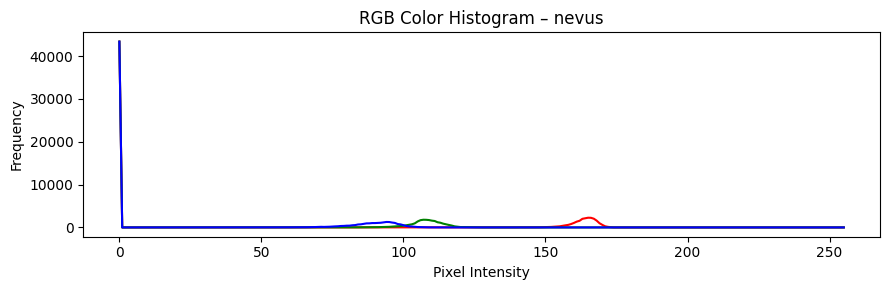

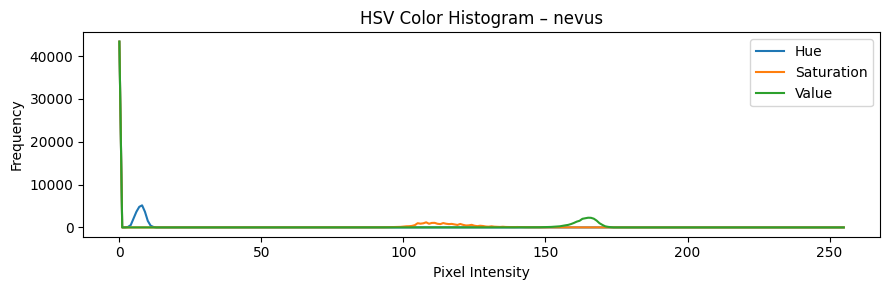

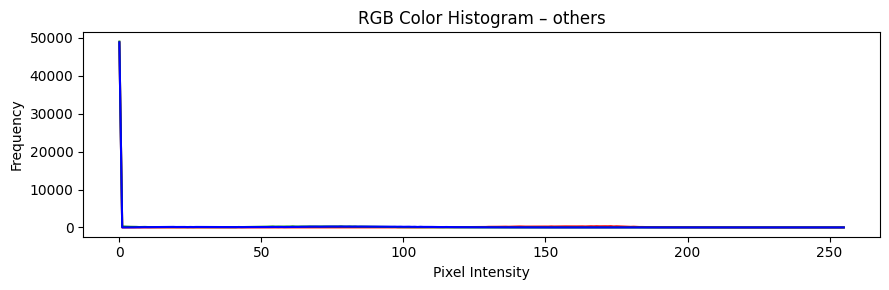

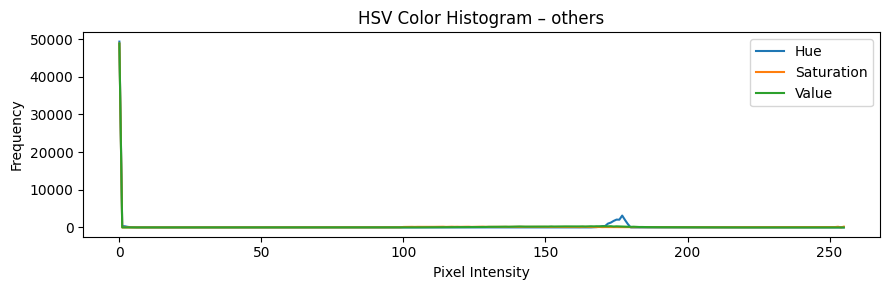

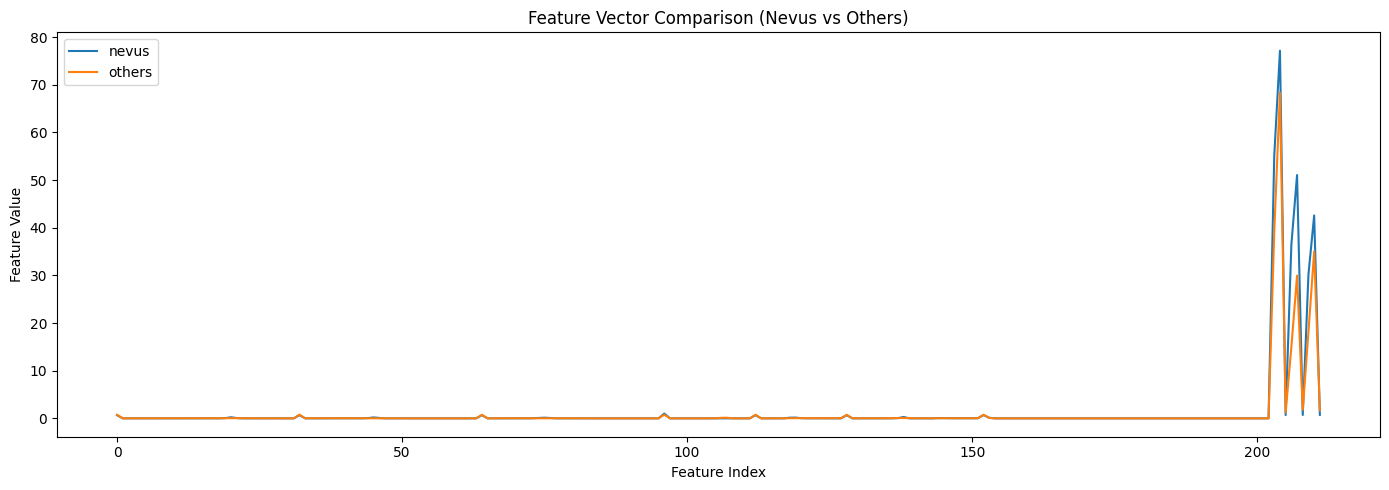


📦 Preparing boxplots for feature distributions...


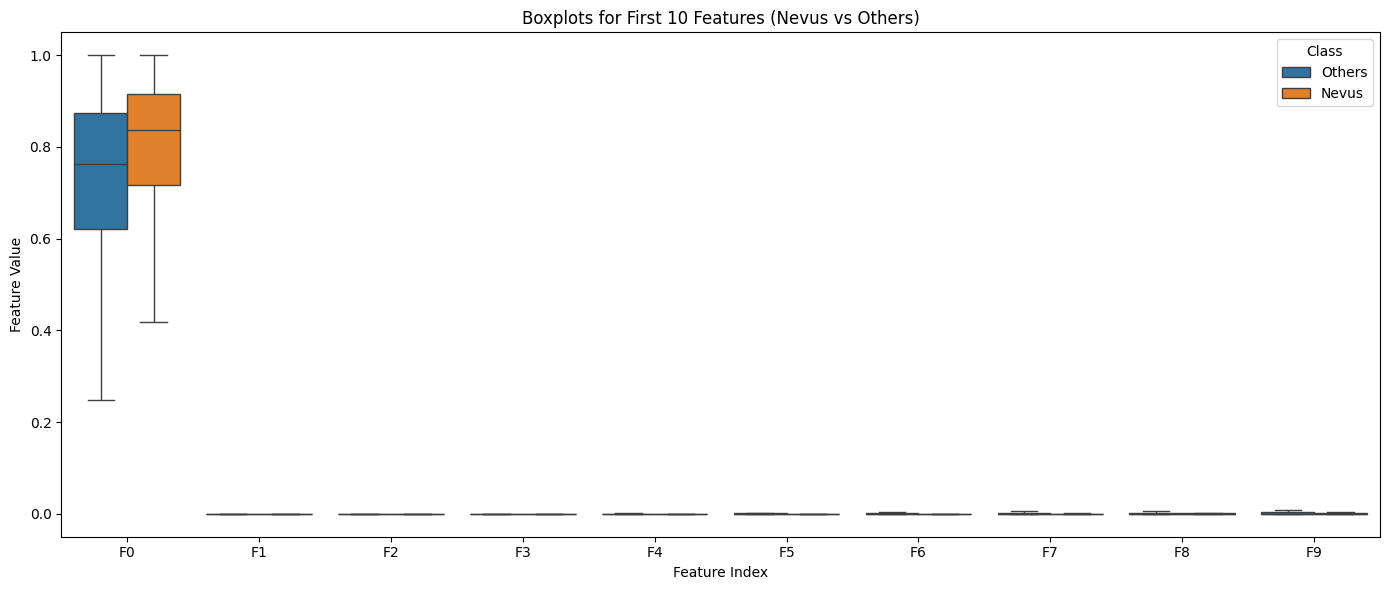


✅ All plots saved to: /content/drive/MyDrive/MIC_UdG/CAD_Lab/Challenge_1/Results/Plots


In [ ]:
# Visualization

import os, cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
from tqdm import tqdm
from skimage.color import rgb2gray


# Paths & Directories

BASE = "/content/drive/MyDrive/MIC_UdG/CAD_Lab/Challenge_1"
TRAIN_DIR = os.path.join(BASE, "Train_Validation")
OUT_DIR = os.path.join(BASE, "Results")
PLOT_DIR = os.path.join(OUT_DIR, "Plots")
os.makedirs(PLOT_DIR, exist_ok=True)

# Class mapping

class_map = {'nevus': 0, 'others': 1}

# Selecting one sample image per class

sample_imgs = {}
for cname in class_map.keys():
    found = glob(os.path.join(TRAIN_DIR, cname, "*.jpg")) + \
            glob(os.path.join(TRAIN_DIR, cname, "*.jpeg")) + \
            glob(os.path.join(TRAIN_DIR, cname, "*.png"))
    if found:
        sample_imgs[cname] = found[0]

if not sample_imgs:
    raise ValueError("No training images found. Check TRAIN_DIR path.")

print("\n Sample images selected:")
for cname, path in sample_imgs.items():
    print(f"   {cname}: {path}")


# Color Histograms

def plot_color_histograms(img, title=""):
    chans = cv2.split(img)
    colors = ("r", "g", "b")

    # RGB Histogram
    plt.figure(figsize=(9,3))
    plt.title(f"RGB Color Histogram – {title}")
    for (ch, col) in zip(chans, colors):
        hist = cv2.calcHist([ch], [0], None, [256], [0,256])
        plt.plot(hist, color=col)
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, f"{title}_RGB_Hist.png"))
    plt.show()

    # HSV Histogram
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
    chans_hsv = cv2.split(hsv)
    labels = ("Hue", "Saturation", "Value")
    plt.figure(figsize=(9,3))
    plt.title(f"HSV Color Histogram – {title}")
    for (ch, lbl) in zip(chans_hsv, labels):
        hist = cv2.calcHist([ch], [0], None, [256], [0,256])
        plt.plot(hist, label=lbl)
    plt.legend()
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, f"{title}_HSV_Hist.png"))
    plt.show()

# Ploting histogram for one image per class
for cname, path in sample_imgs.items():
    img = read_and_segment(path)
    plot_color_histograms(img, title=cname)

# Feature Vector Visualization

def extract_features_for_image(path):
    img = read_and_segment(path)
    rgb_hist = color_histogram_features(img, (32,32,32), 'rgb')
    hsv_hist = color_histogram_features(img, (16,16,16), 'hsv')
    gray = (rgb2gray(img) * 255).astype(np.uint8)
    lbp_hist = lbp_histogram(gray)
    moments = color_moments(img)
    return np.concatenate([rgb_hist, hsv_hist, lbp_hist, moments])

feat_samples = {}
for cname, path in sample_imgs.items():
    feat_samples[cname] = extract_features_for_image(path)

plt.figure(figsize=(14,5))
for cname, vec in feat_samples.items():
    plt.plot(vec, label=cname)
plt.title("Feature Vector Comparison (Nevus vs Others)")
plt.xlabel("Feature Index")
plt.ylabel("Feature Value")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "Feature_Vector_Comparison.png"))
plt.show()

# Boxplots for Feature Distributions

print("\n Preparing boxplots for feature distributions...")

# If training features already exist, reuse them
if 'X' in locals() and 'y' in locals():
    X_box = X
    y_box = y
else:
    # Otherwise, extract small subset
    all_paths, all_labels = [], []
    for cname, lab in class_map.items():
        imgs = glob(os.path.join(TRAIN_DIR, cname, "*.jpg"))[:10]
        all_paths.extend(imgs)
        all_labels.extend([lab]*len(imgs))
    X_box = np.vstack([extract_features_for_image(p) for p in tqdm(all_paths, desc="Extracting subset")])
    y_box = np.array(all_labels)

# Select first 10 features for clarity
n_feats = 10
subset_feats = X_box[:, :n_feats]
feat_df = pd.DataFrame(subset_feats, columns=[f"F{i}" for i in range(n_feats)])
feat_df["Label"] = y_box
feat_df["Class"] = feat_df["Label"].map({0: "Nevus", 1: "Others"})

plt.figure(figsize=(14,6))
sns.boxplot(
    data=pd.melt(feat_df, id_vars="Class", value_vars=[f"F{i}" for i in range(n_feats)]),
    x="variable", y="value", hue="Class", orient="v", dodge=True, showfliers=False
)
plt.title("Boxplots for First 10 Features (Nevus vs Others)")
plt.xlabel("Feature Index")
plt.ylabel("Feature Value")
plt.legend(title="Class")
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "Boxplot_First10Features.png"))
plt.show()

print(f"\n All plots saved to: {PLOT_DIR}")
